Author: Dinghao Luo  
Date  : 26 March 2026

This is a general model of the LC--DA--CA1 PyrUp dataset from Luo et al. (2026), attempting to capture the disparate phenomena using a generic, schematic-style model that formalises DA effects on CA1 pyramidal neurones as a non-linear gain modulation.
This model improves upon the previous model, now saved under `../_defunct`.

This model includes 3 external drives to CA1 pyramidal neurones: 
$$L(t) = {LC~activity}$$
$$R(t)$$
$$W(t)$$
where $R(t)$ is the instantaneous run-related drive, and $W(t)$ is the instantaneous reward-drive.

CA1 pyramidal neurones are modelled using the combination of these processes 
$$x_i(t) = b_i + w_i^R R(t) + w_i^W W(t)$$
$$r_i^0(t) = \phi(x_i(t))$$
$$\tau_a \frac{dz_i}{dt} = -z_i + r_i^0(t)$$
$$m_i(t) = \sigma(\frac{z_i(t) - \theta_i}{\kappa_i})$$
$$r_i(t) = r_i^0(t) [1 + g_i D(t) m_i(t)]$$
where $D(t)$ is the delayed dopamine signal generated from LC activity, $b_i$ is the baseline excitability of each neurone, $w_i^R$ and $w_i^W$ are neurone-specific couplings, $z_i(t)$ is a short-term activity trace, $\theta_i$ is the DA modulatory effect threshold, $\kappa_i$ sets how soft the threshold is, and $g_i$ is DA sensitivity.

The dopamine trace is modelled by
$$k_{DA}(t) = H(t - \delta) A(e^{-\frac{(t-\delta)}{\tau_{decay}}} - e^{-\frac{(t-\delta)}{\tau_{rise}}})$$

In [5]:
# imports
import numpy as np
import matplotlib.pyplot as plt

from dataclasses import dataclass

In [6]:
@dataclass
class PARAMS:
    dt: float     = 0.01  # s
    t_pre: float  = 1.00  # s before run onset 
    t_post: float = 6.00  # s after run onset 

    n_cells: int     = 1000  # CA1 population size 

    # baseline 
    baseline_mean: float = 1.80  # Hz 
    baseline_sd: float   = 0.35

    # run and reward weights
    wR_mean: float = 1.00
    wR_sd: float   = 0.60
    wW_mean: float = 0.60
    wW_sd: float   = 0.60

    # softplus parameters 
    softplus_beta: float = 2.00

    # DA targeting parameters 
    frac_da_targ: float = 0.30
    da_gain: float      = 1.00

    # DA recruitment threshold 
    theta_mean: float = 3.00
    theta_sd: float   = 0.20
    kappa: float      = 0.35
    tau_a: float      = 0.50

    # response-strength calculation
    pre_window: tuple = (-1.00, -0.50)  # s relative to run onset
    post_window: tuple = (0.50, 1.50)

    # class thresholds 
    up_thresh: float   = 3/2
    down_thresh: float = 2/3

    # others 
    eps = 1e-6
    max_rate: float = 20.00  # Hz

In [ ]:
# some housekeeping functions: do response strength calculation, classify cell, make different drives etc.
def window_mask(t, window):
    return (t >= window[0]) & (t < window[1])

def response_strength(rates, t, pre_window, post_window, eps=1e-6):
    '''returns the response strength for each cell'''
    pre_mask = window_mask(t, pre_window)
    post_mask = window_mask(t, post_window)

    pre_mean = np.mean(rates[:, pre_mask], axis=1)
    post_mean = np.mean(rates[:, post_mask], axis=1)

    return post_mean / (pre_mean + eps)

def classify_cells(response_strength, up_thresh=3/2, down_thresh=2/3):
    '''classifies cells into up, down, or other'''
    is_up = response_strength >= up_thresh
    is_down = response_strength <= down_thresh
    is_other = ~(is_up | is_down)

    return {
        'is_up': is_up,
        'is_down': is_down,
        'is_other': is_other
    }

def make_drives

In [ ]:
# simulation code 
def simulate_one_cell(t, p, cell, R, W, D):
    '''
    simulates one cell's FR profile given run, reward, and DA drives
    
    parameters:
    - t: time vector (s)
    - p: PARAMS object
    - cell: dict with keys 'b', 'wR', 'wW', 'theta', 'da_targ'
    - R: run drive (all these drives have the same length as t)
    - W: reward drive
    - D: DA drive

    returns:
    - out: dict containing intermediate variables and final firing rate profile (length = len(t))
    '''
    # inherit timesteps from PARAMS
    dt = p.dt
    if not np.allclose(np.diff(t), dt):  # in case t has shifted from uniform spacing of dt
        raise ValueError('Time vector t must have uniform steps of size p.dt')
    
    # build pre-DA linear drive sum
    x = cell['b'] + cell['wR'] * R + cell['wW'] * W

    # rectify pre-DA drive into non-negative firing rate 
    # we do this with a softplus function to avoid discontinuities in the derivative
    xb = p.softplus_beta * x 
    r0 = (np.log1p(np.exp(-np.abs(xb))) + np.maximum(xb, 0.0)) / p.softplus_beta

    # low-pass filter pre-DA firing state 
    # this would determine whether DA has an effect on this particular cell 
    z = np.zeros_like(r0)
    z[0] = r0[0]

    alpha = p.dt / p.tau_a
    for k in range(1, len(t)):
        z[k] = z[k - 1] + alpha * (-z[k -1] + r0[k - 1])

    # soft DA recruitment gate 
    # for z below threshold, gate stays near 0 
    # for z above threshold, gate approaches 1
    m = 1.0 / (1.0 + np.exp(-(z - cell['theta']) / p.kappa))

    # multiplicative DA gain 
    # note that ONLY if the cell is DA-targeted does DA have an effect (otherwise float(cell['da_targ']) = 0 and gain = 1 regardless of D)
    gain = 1.0 + float(cell['da_targ']) * p.da_gain * m * D
    r = r0 * gain

    # clip firing rate so that it does not explode 
    r = np.clip(r, 0.0, p.max_rate)

    return {
        'x': x,        # latent drive before softplus 
        'r0': r0,      # firing rate before DA
        'z': z,        # smoothed pre-DA state 
        'm': m,        # DA gate 
        'gain': gain,  # multiplicative DA gain 
        'r': r         # final firing rate 
    }

def make_population(p, rng):
    '''
    makes a population of cells with parameters drawn from distributions specified in PARAMS
    '''
    b = rng.normal(p.baseline_mean, p.baseline_sd, p.n_cells)

    wR = rng.normal(p.wR_mean, p.wR_sd, p.n_cells)
    wW = rng.normal(p.wW_mean, p.wW_sd, p.n_cells)

    theta = rng.normal(p.theta_mean, p.theta_sd, p.n_cells)

    da_targ = rng.random(p.n_cells) < p.frac_da_targ

    return {
        'b': b,
        'wR': wR,
        'wW': wW,
        'theta': theta,
        'da_targ': da_targ
    }

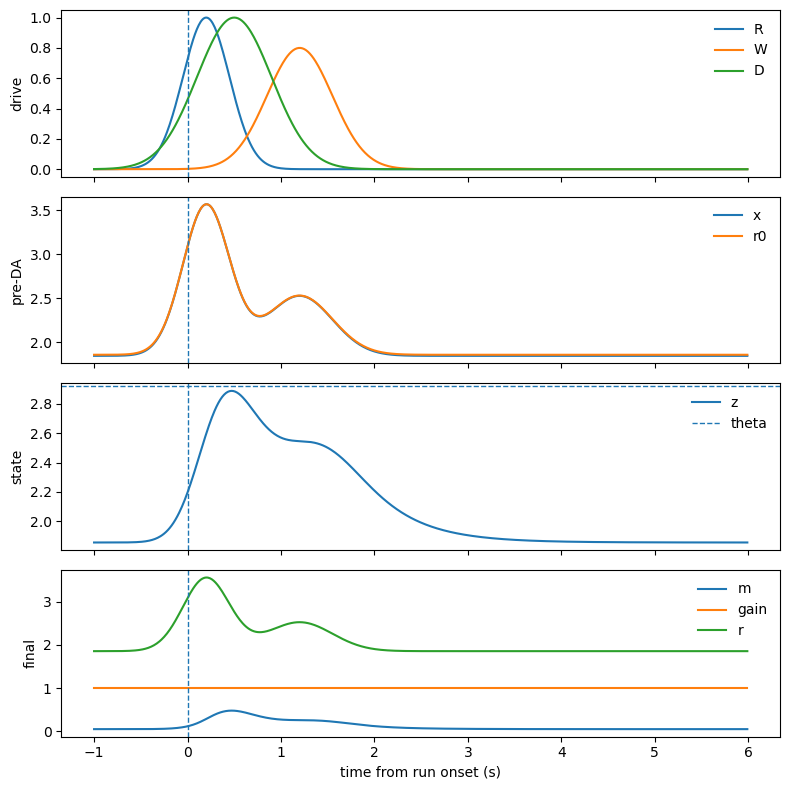

In [9]:
rng = np.random.default_rng(0)
p = PARAMS()

# example time vector
t = np.arange(-p.t_pre, p.t_post, p.dt)

# temporary example drives
# replace these with your real R, W, D once those are defined
R = np.exp(-0.5 * ((t - 0.2) / 0.25)**2)
W = 0.8 * np.exp(-0.5 * ((t - 1.2) / 0.35)**2)
D = np.exp(-0.5 * ((t - 0.5) / 0.4)**2)

pop = make_population(p, rng)

i = 0
cell = {
    'b': pop['b'][i],
    'wR': pop['wR'][i],
    'wW': pop['wW'][i],
    'theta': pop['theta'][i],
    'da_targ': float(pop['da_targ'][i])
}

out = simulate_one_cell(t, p, cell, R, W, D)

fig, axes = plt.subplots(4, 1, figsize=(8, 8), sharex=True)

axes[0].plot(t, R, label='R')
axes[0].plot(t, W, label='W')
axes[0].plot(t, D, label='D')
axes[0].axvline(0, linestyle='--', linewidth=1)
axes[0].legend(frameon=False)
axes[0].set_ylabel('drive')

axes[1].plot(t, out['x'], label='x')
axes[1].plot(t, out['r0'], label='r0')
axes[1].axvline(0, linestyle='--', linewidth=1)
axes[1].legend(frameon=False)
axes[1].set_ylabel('pre-DA')

axes[2].plot(t, out['z'], label='z')
axes[2].axhline(cell['theta'], linestyle='--', linewidth=1, label='theta')
axes[2].axvline(0, linestyle='--', linewidth=1)
axes[2].legend(frameon=False)
axes[2].set_ylabel('state')

axes[3].plot(t, out['m'], label='m')
axes[3].plot(t, out['gain'], label='gain')
axes[3].plot(t, out['r'], label='r')
axes[3].axvline(0, linestyle='--', linewidth=1)
axes[3].legend(frameon=False)
axes[3].set_ylabel('final')
axes[3].set_xlabel('time from run onset (s)')

plt.tight_layout()
plt.show()